# Crawling Data NO2 wilayah sumenep

disini kita akan melakukan Proses untuk mengunduh dan memproses data NO2 (Nitrogen Dioxide) dari satelit Sentinel-5P menggunakan OpenEO API.

1. Import,install library dan koneksi ke Copernicus Data Space Ecosystem

In [3]:
!pip install openeo
!pip install pycaret

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.2/335.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.10.1
    Uninstalling xarray-2025.10.1:
      Successfully uninstalled xarray-2025.10.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 

In [ ]:
import openeo
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xarray as xr


periksa email untuk melakukan coneksi

In [ ]:
# Connect to openEO backend
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=VSHL-LFLX 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


2. kita Definisi Area of Interest (AOI) wilayah Sumenep dan parameter waktu (2021-2025) ambil koordinat pada web geojson.io kemudian blok daerah yang ingin di ambil datannya kemudian salin jsonnya.

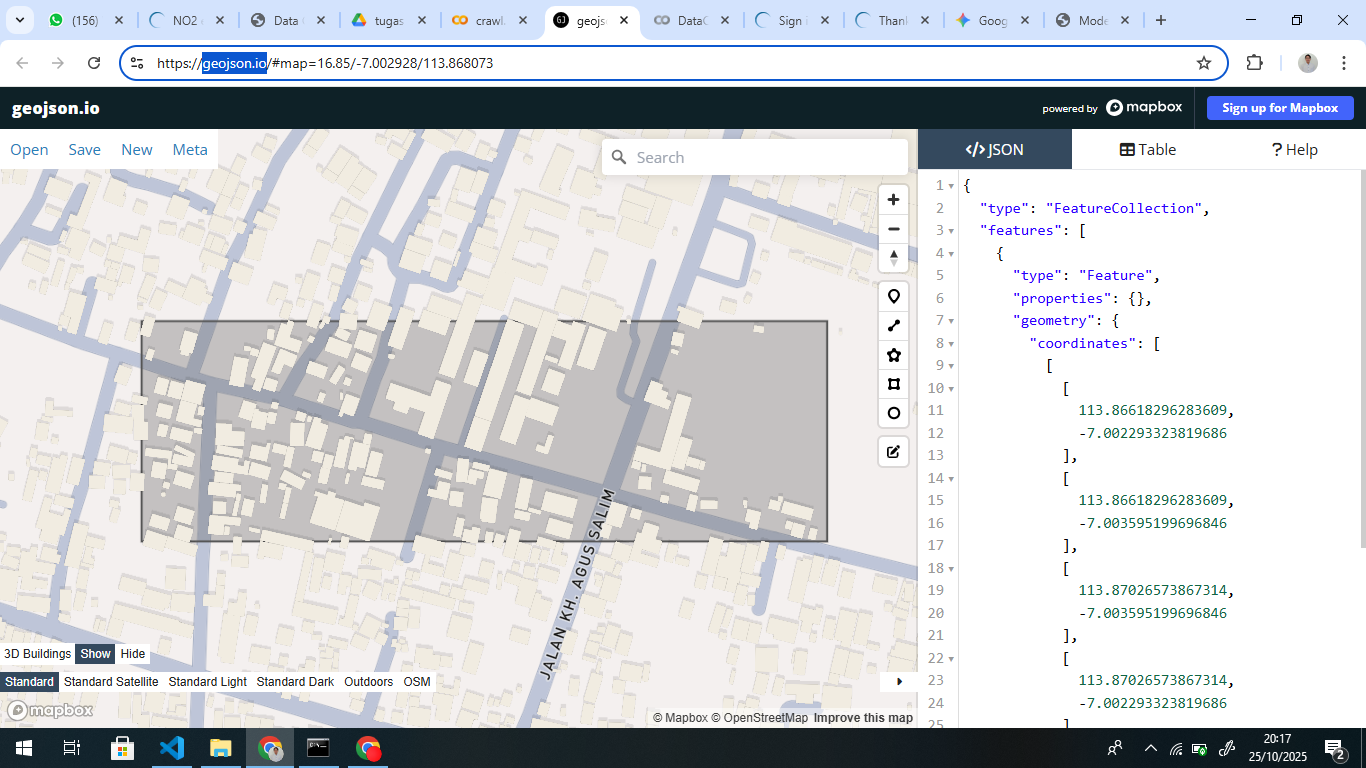

In [ ]:
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              113.86618296283609,
              -7.002293323819686
            ],
            [
              113.86618296283609,
              -7.003595199696846
            ],
            [
              113.87026573867314,
              -7.003595199696846
            ],
            [
              113.87026573867314,
              -7.002293323819686
            ],
            [
              113.86618296283609,
              -7.002293323819686
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

# Define spatial extent from AOI coordinates
spatial_extent = {
    "west": 113.86618296283609,
    "south": -7.003595199696846,
    "east": 113.87026573867314,
    "north": -7.002293323819686
}

start_date = "2025-01-20"
end_date = "2025-10-21"

print(f"AOI defined for coordinates: {spatial_extent}")
print(f"Time range: {start_date} to {end_date}")
print("Setup completed successfully")

AOI defined for coordinates: {'west': 113.86618296283609, 'south': -7.003595199696846, 'east': 113.87026573867314, 'north': -7.002293323819686}
Time range: 2025-01-20 to 2025-10-21
Setup completed successfully


3. Loading data Sentinel-5P NO2 dan agregasi temporal harian

In [ ]:
print("Loading Sentinel-5P NO2 data...")

s5p_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=[start_date, end_date],
    spatial_extent=spatial_extent,
    bands=["NO2"],
)

s5p_monthly = s5p_no2.aggregate_temporal_period(
    period="day",
    reducer="mean"
)
# s5p_monthly = s5p_no2.aggregate_spatial(reducer="mean", geometries=aoi)

print("Data collection and aggregation configured successfully")

Loading Sentinel-5P NO2 data...
Data collection and aggregation configured successfully


4. Melakukan Loading data Sentinel-5P NO2 dan agregasi temporal harian

In [ ]:
print("Starting data processing job...")

job = s5p_monthly.execute_batch(
    title="NO2",
    outputfile="no2_averages_1month.nc"
)


Starting data processing job...
0:00:00 Job 'j-251027005602425c9a302360f4d0a000': send 'start'
0:00:13 Job 'j-251027005602425c9a302360f4d0a000': queued (progress 0%)
0:00:18 Job 'j-251027005602425c9a302360f4d0a000': queued (progress 0%)
0:00:25 Job 'j-251027005602425c9a302360f4d0a000': queued (progress 0%)
0:00:33 Job 'j-251027005602425c9a302360f4d0a000': queued (progress 0%)
0:00:43 Job 'j-251027005602425c9a302360f4d0a000': queued (progress 0%)
0:00:55 Job 'j-251027005602425c9a302360f4d0a000': queued (progress 0%)
0:01:11 Job 'j-251027005602425c9a302360f4d0a000': running (progress N/A)
0:01:30 Job 'j-251027005602425c9a302360f4d0a000': running (progress N/A)
0:01:54 Job 'j-251027005602425c9a302360f4d0a000': running (progress N/A)
0:02:24 Job 'j-251027005602425c9a302360f4d0a000': finished (progress 100%)


5. Mengganti file.nc dengan csv untuk dilakukan preprosesing

In [ ]:
# Buka file NetCDF
ds = xr.open_dataset("no2_averages_1month.nc")

# Ubah ke DataFrame
df = ds.to_dataframe().reset_index()

# Simpan ke CSV
df.to_csv("data_NO2_kedua.csv", index=False)

print("Konversi selesai! File tersimpan sebagai data.csv")


Konversi selesai! File tersimpan sebagai data.csv


## Melakukan Preprosesing data csv NO2

Tahap *preprocessing* ini bertujuan mengubah data deret waktu (time series) NO2 Anda—yang awalnya hanya satu kolom data berurutan—menjadi sebuah tabel yang bisa dipahami oleh model *supervised learning* (seperti model regresi atau *Random Forest*).

Prosesnya adalah sebagai berikut:

1.  **Penanganan Missing Values**: Pertama, Anda "menambal" data yang hilang atau kosong. Pada data waktu, Anda tidak bisa seenaknya menghapus baris, jadi Anda mengisinya menggunakan metode seperti **interpolasi** (menebak nilai di antara dua titik yang ada) atau **rata-rata bergerak** (*rolling average*).

2.  **Transformasi Supervised & Lag Features**: Ini adalah inti prosesnya. Anda mengubah format data dengan prinsip bahwa **nilai NO2 di masa depan (`y`) dipengaruhi oleh nilai NO2 di masa lalu (`X`)**.
    * **Lag features** adalah "fitur" `X` yang Anda buat dengan cara menggeser data.
    * Contoh: Untuk memprediksi nilai NO2 hari ini (target `y`), Anda membuat fitur baru berupa nilai NO2 kemarin (lag 1), dua hari lalu (lag 2), tiga hari lalu (lag 3), dan seterusnya.

Hasil akhirnya adalah sebuah tabel di mana setiap baris berisi fitur-fitur (nilai lag) dan satu target (nilai yang ingin diprediksi), siap untuk dilatih oleh model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("data_NO2_kedua.csv")

print("Preview Data:")
print(df.head())

print("\nInfo Data Awal:")
print(df.info())

print(f"\nShape dataset: {df.shape}")
print(f"Kolom dataset: {df.columns.tolist()}")

Preview Data:
            t           x         y  crs  NO2
0  2025-01-20  113.893465 -6.986234  b''  NaN
1  2025-01-21  113.893465 -6.986234  b''  NaN
2  2025-01-22  113.893465 -6.986234  b''  NaN
3  2025-01-23  113.893465 -6.986234  b''  NaN
4  2025-01-24  113.893465 -6.986234  b''  NaN

Info Data Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       273 non-null    object 
 1   x       273 non-null    float64
 2   y       273 non-null    float64
 3   crs     273 non-null    object 
 4   NO2     129 non-null    float64
dtypes: float64(3), object(2)
memory usage: 10.8+ KB
None

Shape dataset: (273, 5)
Kolom dataset: ['t', 'x', 'y', 'crs', 'NO2']


## Melakukan konversi tanggal dan sorting data


Langkah ini adalah fondasi penting dalam analisis *time series*. Tujuannya adalah untuk memastikan data Anda **terstruktur secara kronologis** dan dapat dipahami oleh komputer sebagai urutan waktu, bukan hanya teks biasa.

## Penjelasan

### 1. Konversi Tanggal (Menjadi Tipe `datetime`) 🗓️
* **Masalah:** Saat data dimuat, komputer seringkali membaca tanggal (misalnya, "10/07/2025") hanya sebagai **teks atau *string***. Komputer tidak tahu bahwa itu adalah tanggal; ia hanya melihatnya sebagai kumpulan karakter.
* **Solusi:** Anda mengonversinya menjadi objek **`datetime`**. Ini adalah tipe data khusus yang memberitahu Python, "Ini bukan teks biasa, ini adalah titik waktu yang spesifik."
* **Mengapa Penting?** Setelah diubah, Anda bisa melakukan operasi waktu yang kuat, seperti:
    * Menghitung selisih (misalnya, "berapa hari antara dua kejadian").
    * Mengambil data berdasarkan rentang waktu (misalnya, "tampilkan semua data dari bulan Januari").
    * Membuat plot grafik dengan sumbu-x yang benar-benar merepresentasikan waktu.

### 2. Sorting Data (Mengurutkan Berdasarkan Waktu) 📈
* **Masalah:** Data mentah seringkali tidak berurutan. Anda mungkin mendapatkan data dari tanggal 10, lalu tanggal 5, lalu tanggal 20.
* **Solusi:** Anda **mengurutkan** seluruh dataset berdasarkan kolom `datetime` yang baru saja Anda buat, dari yang paling lampau (awal) hingga yang paling baru (akhir).
* **Mengapa Penting?** Analisis *time series* secara fundamental mempelajari **pola berdasarkan urutan**. Jika urutannya salah, polanya akan hancur.
    * **Analogi Sederhana:** Ini seperti mencoba menonton film dengan adegan-adegan yang diacak. Anda tidak akan pernah mengerti ceritanya. Sorting memastikan Anda menonton "film" data Anda dari awal hingga akhir dengan benar, sehingga pola seperti tren atau musiman menjadi jelas.

Secara singkat, langkah ini mengubah data Anda dari "kumpulan catatan acak" menjadi "alur cerita kronologis" yang siap untuk dianalisis.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

df["t"] = pd.to_datetime(df["t"], format="%Y-%m-%d")
df = df.sort_values('t').reset_index(drop=True)

print("Data setelah konversi datetime:")
print(df.head())
print(f"Rentang tanggal: {df['t'].min()} sampai {df['t'].max()}")

Data setelah konversi datetime:
           t           x         y  crs  NO2
0 2025-01-20  113.893465 -6.986234  b''  NaN
1 2025-01-21  113.893465 -6.986234  b''  NaN
2 2025-01-22  113.893465 -6.986234  b''  NaN
3 2025-01-23  113.893465 -6.986234  b''  NaN
4 2025-01-24  113.893465 -6.986234  b''  NaN
Rentang tanggal: 2025-01-20 00:00:00 sampai 2025-10-20 00:00:00


3. Handling Missing Values
Langkah ini sangat penting untuk "menambal" lubang atau data yang hilang (NaN) dalam time series Anda. Anda tidak bisa begitu saja menghapus baris yang hilang, karena itu akan merusak urutan waktu data.

1. Identifikasi Missing Values
Langkah pertama adalah memindai data Anda untuk menemukan di mana "lubang" itu berada. Ini bisa berupa satu hari di mana sensor gagal mencatat data, atau beberapa hari berturut-turut.

2. Mengisi dengan Interpolasi Linier
Ini adalah inti dari prosesnya. Interpolasi linier adalah metode cerdas untuk mengisi kekosongan dengan cara "menarik garis lurus" di antara dua titik data yang diketahui.

Analogi Sederhana: Bayangkan Anda melacak suhu. Data Anda menunjukkan:

Senin: 10°C

Selasa: (Datanya hilang)

Rabu: 20°C

Interpolasi linier akan secara otomatis mengisi nilai hari Selasa dengan 15°C, yaitu nilai yang berada tepat di tengah-tengah (di garis lurus) antara 10°C dan 20°C.

Mengapa Ini Penting? Metode ini jauh lebih baik daripada hanya mengisi dengan nilai rata-rata keseluruhan (misalnya 25°C) karena ia mempertahankan tren lokal dalam data. Jika data sedang dalam tren naik, nilai yang diinterpolasi juga akan berada di jalur naik tersebut.

3. Menyimpan ke File Baru
Setelah semua lubang ditambal, Anda menyimpan DataFrame yang sudah bersih ini ke file baru (misalnya, no2_cleaned.csv).

Mengapa Ini Penting? Ini adalah praktik terbaik dalam data science. Anda tidak pernah menimpa data mentah asli Anda. Data asli adalah aset berharga. Dengan menyimpan hasil preprocessing ke file baru, Anda membuat "checkpoint" data bersih yang siap digunakan untuk analisis atau modeling, sambil tetap menyimpan data aslinya jika Anda perlu mengulang atau mencoba metode pembersihan lain.

In [ ]:
print("Missing values sebelum preprocessing:")
missing_before = df.isnull().sum()
print(missing_before)

missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPersentase missing values:")
for col, percent in missing_percent.items():
    if percent > 0:
        print(f"{col}: {percent:.2f}%")

if df.isnull().sum().sum() > 0:
    print("\nMelakukan interpolasi linier untuk missing values...")

    df_processed = df.copy()

    numeric_columns = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_columns:
        if df_processed[col].isnull().sum() > 0:
            print(f"Interpolasi kolom {col}: {df_processed[col].isnull().sum()} missing values")

            df_processed[col] = df_processed[col].interpolate(method='linear')

            df_processed[col] = df_processed[col].fillna(method='ffill').fillna(method='bfill')

    print("\nMissing values setelah interpolasi:")
    missing_after = df_processed.isnull().sum()
    print(missing_after)

    output_filename = "timeseries_NO2_preprocessed.csv"
    df_processed.to_csv(output_filename, index=False)

    print(f"\nData berhasil diproses dan disimpan ke: {output_filename}")
    print(f"Shape data asli: {df.shape}")
    print(f"Shape data processed: {df_processed.shape}")

Missing values sebelum preprocessing:
t        0
x        0
y        0
crs      0
NO2    144
dtype: int64

Persentase missing values:
NO2: 52.75%

Melakukan interpolasi linier untuk missing values...
Interpolasi kolom NO2: 144 missing values

Missing values setelah interpolasi:
t      0
x      0
y      0
crs    0
NO2    0
dtype: int64

Data berhasil diproses dan disimpan ke: timeseries_NO2_preprocessed.csv
Shape data asli: (273, 5)
Shape data processed: (273, 5)


/tmp/ipython-input-1108620982.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_processed[col] = df_processed[col].fillna(method='ffill').fillna(method='bfill')


## Pembuatan Supervised Data dengan Lag Features

Tentu, ini adalah langkah paling penting dalam mengubah masalah *time series* menjadi masalah *supervised learning*.

Secara singkat, langkah ini **mengubah format data Anda dari "satu kolom panjang" menjadi "tabel lebar"** dengan banyak fitur (`X`) dan satu target (`y`). Model *machine learning* standar (seperti *Random Forest* atau Regresi Linier) tidak bisa memahami "urutan waktu", tapi mereka sangat pandai menemukan pola dalam tabel.

---
## 1. Pembuatan Lag Features (Konteks Historis)

Ini adalah inti dari transformasi. Anda membuat fitur `X` (prediktor) dengan cara "menggeser" data nilai NO2 ke belakang.

* **Masalah:** Bagaimana model bisa memprediksi nilai hari ini?
* **Solusi:** Beri tahu model nilai-nilai dari hari kemarin, 2 hari lalu, 3 hari lalu, dst. Nilai-nilai historis ini disebut **"Lag Features"**.

**Analogi:** Anda tidak bisa memprediksi lalu lintas besok (`y`) hanya dengan melihat kalender. Tapi jika Anda tahu data lalu lintas hari ini (`lag 1`), kemarin (`lag 2`), dan 7 hari lalu (`lag 7`), prediksi Anda akan jauh lebih baik.

#### Contoh Transformasi:

**Data Asli (Time Series):**
| Tanggal | NO2 |
| :--- | :--- |
| 1 Jan | 20 |
| 2 Jan | 22 |
| 3 Jan | 25 |
| 4 Jan | 23 |

**Data Baru (Supervised Format) dengan 2 Lag:**
| Tanggal | Lag_2 (X2) | Lag_1 (X1) | **NO2 (y)** |
| :--- | :--- | :--- | :--- |
| 3 Jan | 20 | 22 | **25** |
| 4 Jan | 22 | 25 | **23** |
*(Baris 1 & 2 dihapus karena datanya tidak lengkap)*

Sekarang, model bisa belajar pola seperti: "Jika `Lag_2` adalah 20 dan `Lag_1` adalah 22, maka target `y` kemungkinan adalah 25."

---
## 2. Penambahan Fitur Temporal (Konteks Kalender)

*Lag features* saja tidak cukup. Model juga perlu tahu konteks *kapan* data itu terjadi. Anda mengekstrak informasi ini langsung dari tanggal.

* **Fitur:** `year`, `month`, `day`, `dayofweek` (misal: Senin=0, Minggu=6).
* **Mengapa Penting?** Fitur-fitur ini membantu model menangkap pola yang lebih besar:
    * **Pola Mingguan (`dayofweek`):** Level NO2 mungkin lebih rendah di akhir pekan (Sabtu/Minggu) daripada di hari kerja.
    * **Pola Musiman (`month`):** Level NO2 mungkin lebih tinggi di musim dingin (Bulan 12, 1, 2) daripada di musim panas.
    * **Pola Jangka Panjang (`year`):** Level NO2 mungkin memiliki tren menurun secara keseluruhan dari tahun ke tahun.

---
## 3. Pembuatan Fitur Siklik (Konteks Berulang)

Ini adalah cara yang lebih "pintar" untuk merepresentasikan fitur temporal seperti `month` atau `dayofweek`.

* **Masalah:** Jika Anda menggunakan angka 1-12 untuk `month`, model akan berpikir bahwa 1 (Januari) dan 12 (Desember) sangat "jauh" secara numerik. Padahal, dalam kenyataannya, kedua bulan ini sangat "dekat" (bersebelahan dalam satu siklus).

* **Solusi:** Anda merepresentasikan waktu dalam lingkaran (siklus) menggunakan **Sinus (`sin`)** dan **Kosinus (`cos`)**.



* **Cara Kerja:** Kombinasi nilai `sin` dan `cos` akan memberi tahu model di mana tepatnya posisi data dalam sebuah siklus.
    * `month_sin` dan `month_cos` memberi tahu model siklus 12 bulan.
    * `day_sin` dan `day_cos` memberi tahu model siklus 24 jam (jika data per jam) atau siklus mingguan.
* **Keuntungan:** Dengan cara ini, model akan paham bahwa Desember (Bulan 12) secara mulus kembali ke Januari (Bulan 1), sama seperti jam 23:00 kembali ke jam 00:00.

**Hasil Akhir:** Anda mendapatkan sebuah tabel data yang "lebar", di mana setiap baris berisi semua informasi (`X`) yang diperlukan (nilai lag, info kalender, info siklik) untuk memprediksi nilai target (`y`).

In [ ]:
def create_supervised_data(data, n_lags=7, target_col='NO2_mean'):
    df_supervised = data.copy()

    df_supervised = df_supervised.sort_values('t').reset_index(drop=True)

    print(f"Membuat {n_lags} lag features untuk prediksi...")

    for i in range(1, n_lags + 1):
        df_supervised[f'{target_col}_lag_{i}'] = df_supervised[target_col].shift(i)

    df_supervised['year'] = df_supervised['t'].dt.year
    df_supervised['month'] = df_supervised['t'].dt.month
    df_supervised['day'] = df_supervised['t'].dt.day
    df_supervised['dayofweek'] = df_supervised['t'].dt.dayofweek
    df_supervised['dayofyear'] = df_supervised['t'].dt.dayofyear

    df_supervised['month_sin'] = np.sin(2 * np.pi * df_supervised['month'] / 12)
    df_supervised['month_cos'] = np.cos(2 * np.pi * df_supervised['month'] / 12)
    df_supervised['day_sin'] = np.sin(2 * np.pi * df_supervised['day'] / 31)
    df_supervised['day_cos'] = np.cos(2 * np.pi * df_supervised['day'] / 31)

    df_supervised = df_supervised.dropna().reset_index(drop=True)

    return df_supervised


df_clean = pd.read_csv("timeseries_NO2_preprocessed.csv")
df_clean['t'] = pd.to_datetime(df_clean['t'])
print("Menggunakan data preprocessed...")

target_columns = [col for col in df_clean.columns if 'NO2' in col.upper() or 'no2' in col]
if target_columns:
    target_col = target_columns[0]
    print(f"Kolom target: {target_col}")
else:
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    target_col = numeric_cols[0] if len(numeric_cols) > 0 else 'value'
    print(f"Kolom target (otomatis): {target_col}")

lag_options = [7]
for n_lags in lag_options:
    print(f"\nMEMBUAT SUPERVISED DATA DENGAN {n_lags} LAG")

    df_supervised = create_supervised_data(df_clean, n_lags=n_lags, target_col=target_col)

    print(f"Shape supervised data: {df_supervised.shape}")
    print(f"Features yang dibuat: {n_lags} lag features + 8 temporal features")

    feature_cols = [col for col in df_supervised.columns
                   if col not in ['t', target_col] and not col.startswith('Unnamed')]

    X = df_supervised[feature_cols]
    y = df_supervised[target_col]

    print(f"Features (X) shape: {X.shape}")
    print(f"Target (y) shape: {y.shape}")
    print(f"Feature columns: {feature_cols}")

    output_filename = f"supervised_data_lag_{n_lags}.csv"
    df_supervised.to_csv(output_filename, index=False)
    print(f"Supervised data disimpan ke: {output_filename}")

    print(f"\nContoh supervised data (5 baris pertama):")
    print(df_supervised[['t'] + feature_cols[:5] + [target_col]].head())

print("\nFile yang dibuat:")
for n_lags in lag_options:
    print(f"- supervised_data_lag_{n_lags}.csv")

Menggunakan data preprocessed...
Kolom target: NO2

MEMBUAT SUPERVISED DATA DENGAN 7 LAG
Membuat 7 lag features untuk prediksi...
Shape supervised data: (266, 21)
Features yang dibuat: 7 lag features + 8 temporal features
Features (X) shape: (266, 19)
Target (y) shape: (266,)
Feature columns: ['x', 'y', 'crs', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_4', 'NO2_lag_5', 'NO2_lag_6', 'NO2_lag_7', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'month_sin', 'month_cos', 'day_sin', 'day_cos']
Supervised data disimpan ke: supervised_data_lag_7.csv

Contoh supervised data (5 baris pertama):
           t           x         y  crs  NO2_lag_1  NO2_lag_2       NO2
0 2025-01-27  113.893465 -6.986234  b''   0.000023   0.000023  0.000023
1 2025-01-28  113.893465 -6.986234  b''   0.000023   0.000023  0.000023
2 2025-01-29  113.893465 -6.986234  b''   0.000023   0.000023  0.000023
3 2025-01-30  113.893465 -6.986234  b''   0.000023   0.000023  0.000023
4 2025-02-01  113.893465 -6.986234  b''  

## Melakukan modeling dengan KNN regresion

Implementasi KNN Regression untuk forecasting data time series NO2 dengan lag 7.

1. Import Library

Langkah pertama adalah menyiapkan 'peralatan' (library) ⚙️ yang kita butuhkan. Kita akan mengimpor **`pandas`** untuk memuat dan mengatur tabel data *time series* NO2 kita, dan **`numpy`** untuk menangani operasi numerik.

Untuk visualisasi, kita menggunakan **`matplotlib`** dan **`seaborn`** untuk membuat plot yang membandingkan data asli dengan hasil *forecast*. Terakhir, yang paling penting adalah **`scikit-learn`**, yang berisi 'otak' dari model kita (yaitu `KNeighborsRegressor`) serta metrik evaluasi (seperti *Mean Squared Error*) untuk mengukur seberapa akurat prediksi kita.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

2. Load Dataset Supervised
Pada langkah ini, kita memuat file data yang sudah ditransformasi 💾. Ini bukan lagi data deret waktu mentah, melainkan sebuah tabel 'pintar' yang siap untuk *supervised learning*.

Setiap baris dalam dataset ini secara efektif berisi:
* **Fitur (`X`):** Nilai-nilai NO2 dari 7 hari sebelumnya (lag 1 hingga 7).
* **Target (`y`):** Nilai NO2 'hari ini' (yang ingin kita prediksi).

In [ ]:
df = pd.read_csv('supervised_data_lag_7.csv')
print("Shape dataset:", df.shape)
df.head()

Shape dataset: (266, 21)


,t,x,y,crs,NO2,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_4,NO2_lag_5,...,NO2_lag_7,year,month,day,dayofweek,dayofyear,month_sin,month_cos,day_sin,day_cos
0,2025-01-27,113.893465,-6.986234,b'',0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000023,2025,1,27,0,27,0.500000,0.866025,-0.724793,0.688967
1,2025-01-28,113.893465,-6.986234,b'',0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000023,2025,1,28,1,28,0.500000,0.866025,-0.571268,0.820763
2,2025-01-29,113.893465,-6.986234,b'',0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000023,2025,1,29,2,29,0.500000,0.866025,-0.394356,0.918958
3,2025-01-30,113.893465,-6.986234,b'',0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000023,2025,1,30,3,30,0.500000,0.866025,-0.201299,0.979530
4,2025-02-01,113.893465,-6.986234,b'',0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000023,2025,2,1,5,32,0.866025,0.500000,0.201299,0.979530


3. Explorasi Data
Ini adalah langkah "cek kesehatan" 🩺 data kita. Sebelum melatih model, kita harus memastikan data kita bersih dan kita memahaminya.

Proses ini meliputi:
1.  **Informasi Tipe Data:** Kita memeriksa apakah semua kolom angka sudah terbaca sebagai angka (`int`/`float`) dan bukan teks.
2.  **Deskripsi Statistik:** Kita melihat nilai **minimum, maksimum, dan rata-rata** dari setiap kolom. Ini membantu kita melihat apakah ada nilai yang aneh atau di luar jangkauan yang wajar.
3.  **Pengecekan *Missing Values*:** Kita melakukan pemeriksaan akhir untuk memastikan tidak ada data yang 'bolong' (`NaN`) yang terlewat dari proses *preprocessing* sebelumnya.

Jika semua terlihat bagus, kita bisa percaya diri untuk melanjutkan ke tahap *modeling*.

In [ ]:
# Informasi dataset
print("Info Dataset:")
print(df.info())
print("\nDeskripsi Statistik:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   t          266 non-null    object 
 1   x          266 non-null    float64
 2   y          266 non-null    float64
 3   crs        266 non-null    object 
 4   NO2        266 non-null    float64
 5   NO2_lag_1  266 non-null    float64
 6   NO2_lag_2  266 non-null    float64
 7   NO2_lag_3  266 non-null    float64
 8   NO2_lag_4  266 non-null    float64
 9   NO2_lag_5  266 non-null    float64
 10  NO2_lag_6  266 non-null    float64
 11  NO2_lag_7  266 non-null    float64
 12  year       266 non-null    int64  
 13  month      266 non-null    int64  
 14  day        266 non-null    int64  
 15  dayofweek  266 non-null    int64  
 16  dayofyear  266 non-null    int64  
 17  month_sin  266 non-null    float64
 18  month_cos  266 non-null    float64
 19  day_sin    266 non-null    float64
 

4. Persiapan Data untuk Modeling
Langkah ini adalah tentang **menyusun strategi** 🎯. Kita melihat semua kolom yang kita miliki dan memutuskan peran masing-masing.

Secara spesifik, kita membagi data menjadi dua kelompok:

1.  **Target (`y`):** Ini adalah **jawaban** yang ingin kita prediksi. Dalam kasus Anda, ini adalah kolom `NO2` (nilai NO2 'hari ini').
2.  **Fitur (`X`):** Ini adalah **petunjuk** yang akan kita berikan kepada model untuk menebak jawaban. Ini adalah semua kolom *selain* target, seperti `lag_1`, `lag_2`, `month_sin`, `dayofweek`, dan lain-lain.

In [ ]:
print("Kolom dalam dataset:")
print(df.columns.tolist())

if 'NO2' in df.columns:
    target_col = 'NO2'
else:
    target_col = df.columns[-1]

print(f"\nKolom target: {target_col}")

Kolom dalam dataset:
['t', 'x', 'y', 'crs', 'NO2', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_4', 'NO2_lag_5', 'NO2_lag_6', 'NO2_lag_7', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Kolom target: NO2


5. Pemisahan Fitur dan Target
Ini adalah langkah **pemilihan fitur (*feature selection*)** yang sangat spesifik dan menentukan.

Anda secara sadar menyederhanakan model untuk fokus secara eksklusif pada **pola autoregresif** data—yaitu, memprediksi nilai NO2 di masa depan *hanya* berdasarkan nilai NO2 di masa lalu.

---
## Implikasi dari Pilihan Ini

Dengan membuang semua fitur temporal dan siklik (`dayofweek`, `month_sin`, dll.), Anda membuat model yang "buta" terhadap konteks kalender. Model Anda tidak akan tahu perbedaan antara:

* **Hari Kerja vs. Akhir Pekan:** Model tidak bisa membedakan apakah `lag_1` (kemarin) adalah hari Minggu (lalu lintas rendah) atau Senin (lalu lintas tinggi).
* **Musim Panas vs. Musim Dingin:** Model tidak tahu apakah data berasal dari bulan Januari (saat NO2 mungkin lebih tinggi) atau Juli (saat NO2 mungkin lebih rendah).

Model ini dipaksa untuk menemukan pola *hanya* dari momentum internal data (nilai-nilai lag), tanpa bantuan konteks eksternal kapan kejadian itu terjadi.


--- Deteksi Outlier dengan LOF ---
Jumlah outlier yang terdeteksi: 16

--- Normalisasi Data Fitur (MinMaxScaler) ---
Contoh data ternormalisasi (5 baris pertama):
   NO2_lag_1  NO2_lag_2  NO2_lag_3  NO2_lag_4  NO2_lag_5  NO2_lag_6  \
0   0.599926   0.599926   0.599926   0.599926   0.599926   0.599926   
1   0.599926   0.599926   0.599926   0.599926   0.599926   0.599926   
2   0.599926   0.599926   0.599926   0.599926   0.599926   0.599926   
3   0.599926   0.599926   0.599926   0.599926   0.599926   0.599926   
4   0.599926   0.599926   0.599926   0.599926   0.599926   0.599926   

   NO2_lag_7  is_outlier  
0   0.599926           1  
1   0.599926           1  
2   0.599926           1  
3   0.599926           1  
4   0.599926           1  

--- Analisis Autokorelasi (ACF) ---


<Figure size 1000x500 with 0 Axes>

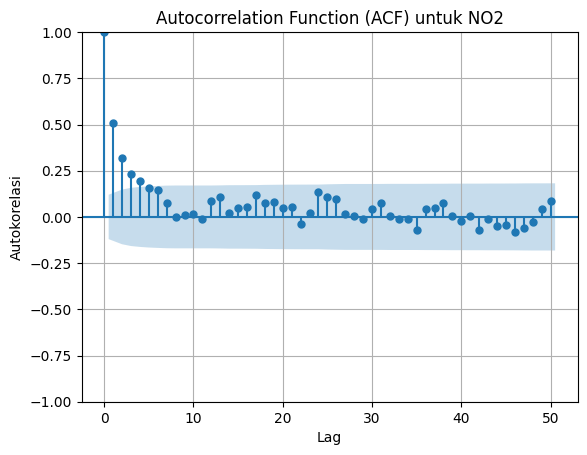

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf

# 2. DETEKSI OUTLIER DENGAN LOCAL OUTLIER FACTOR (LOF)
print("\n--- Deteksi Outlier dengan LOF ---")
# n_neighbors: Jumlah tetangga terdekat yang digunakan.
# contamination: Perkiraan proporsi outlier dalam data. 'auto' mencoba untuk mendeteksinya.
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')

# y_pred_outliers akan berisi -1 untuk outlier dan 1 untuk inlier
y_pred_outliers = lof.fit_predict(X)

# Tambahkan status outlier ke X
X['is_outlier'] = y_pred_outliers

# Jumlah outlier yang terdeteksi
outlier_count = (y_pred_outliers == -1).sum()
print(f"Jumlah outlier yang terdeteksi: {outlier_count}")

# Anda dapat memfilter X untuk hanya menyertakan data non-outlier jika diperlukan:
# X_inliers = X[X['is_outlier'] == 1].drop(columns=['is_outlier'])


# 3. NORMALISASI DATA FITUR (MinMaxScaler)
print("\n--- Normalisasi Data Fitur (MinMaxScaler) ---")

# Normalisasi hanya pada kolom fitur numerik (dengan mengecualikan kolom 'is_outlier')
X_to_scale = X.drop(columns=['is_outlier'])
scaler = MinMaxScaler()

# Lakukan fit dan transform
X_normalized = scaler.fit_transform(X_to_scale)

# Konversi kembali ke DataFrame
X_normalized_df = pd.DataFrame(X_normalized, columns=X_to_scale.columns)
X_normalized_df['is_outlier'] = X['is_outlier'].values # Tambahkan kembali status outlier

print("Contoh data ternormalisasi (5 baris pertama):")
print(X_normalized_df.head())


# 4. ANALISIS AUTOKORELASI (ACF Plot)
print("\n--- Analisis Autokorelasi (ACF) ---")
plt.figure(figsize=(10, 5))
# plot_acf akan menampilkan seberapa besar korelasi nilai saat ini (t) dengan nilai masa lalu (t-lag)
plot_acf(y, lags=50, alpha=0.05) # lags=50 untuk 50 periode waktu ke belakang
plt.title(f'Autocorrelation Function (ACF) untuk {target_col}')
plt.xlabel('Lag')
plt.ylabel('Autokorelasi')
plt.grid(True)
plt.show() # Tampilkan plot
# plt.savefig('autocorrelation_acf_plot.png') # Simpan pl

In [ ]:
X = df.drop(
    columns=[
        target_col,
        "t",
        'NO2_lag_6', 'NO2_lag_7',
        "x",
        "y",
        "crs",
        "day",
        "dayofweek",
        "year",
        "month",
        "dayofyear",
        "month_sin",
        "month_cos",
        "day_sin",
        "day_cos",
    ]
)
y = df[target_col]

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nKolom fitur yang digunakan:\n{X.columns.tolist()}")


Shape X: (266, 5)
Shape y: (266,)

Kolom fitur yang digunakan:
['NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_4', 'NO2_lag_5']


6. Split Data Train dan Test
Ini adalah langkah krusial untuk mengevaluasi model *time series* secara jujur ⏱️.

Kita membagi data menjadi dua bagian:
1.  **Data Training (80% pertama):** Ini adalah data "masa lalu" yang kita gunakan untuk **melatih** model.
2.  **Data Testing (20% terakhir):** Ini adalah data "masa depan" yang kita **sembunyikan** dari model. Model akan diuji seberapa baik ia bisa memprediksi data ini.

---
### Mengapa `shuffle=False` Sangat Penting?

Dalam *time series*, **urutan data adalah segalanya**. Anda harus selalu melatih model pada data masa lalu untuk memprediksi data di masa depan.

* **Apa yang terjadi jika `shuffle=True` (diacak)?** 🔀
    Model Anda bisa secara tidak sengaja dilatih menggunakan data dari hari Jumat untuk memprediksi data hari Selasa. Ini adalah "kebocoran data" (*data leakage*), karena model melihat data dari masa depan saat berlatih. Akibatnya, performa model akan terlihat sangat bagus saat diuji, tetapi itu bohong.

* **Dengan `shuffle=False` (tidak diacak):**
    Anda memastikan data terbelah secara kronologis. Model hanya akan dilatih pada 80% data terawal (misalnya, data Januari-September) dan diuji pada 20% data terakhir (data Oktober-Desember). Ini secara akurat mensimulasikan skenario *forecasting* di dunia nyata.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

print("Shape data train:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print("\nShape data test:")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Shape data train:
X_train: (212, 5), y_train: (212,)

Shape data test:
X_test: (54, 5), y_test: (54,)


7. Normalisasi Data
Ini adalah langkah yang **wajib** dilakukan untuk KNN 📏.

Kita menerapkan `StandardScaler` pada data fitur kita (baik data latih maupun data uji). Proses ini mengubah setiap fitur sehingga memiliki **rata-rata (mean) 0** dan **standar deviasi 1**.

## Mengapa Ini Sangat Penting untuk KNN?

KNN adalah **algoritma berbasis jarak** (*distance-based algorithm*). Ia bekerja dengan mengukur jarak (seperti jarak Euclidean) antar titik data untuk menemukan "tetangga terdekat".

* **Masalah:** Bayangkan Anda memiliki dua fitur *lag*. Fitur `lag_1` memiliki rentang nilai antara 50-100, sementara `lag_7` memiliki rentang nilai antara 10-20. Tanpa normalisasi, angka-angka besar dari `lag_1` akan **mendominasi** perhitungan jarak. Model akan salah mengira bahwa `lag_1` jauh lebih penting daripada `lag_7`, hanya karena angkanya lebih besar.
* **Solusi:** `StandardScaler` "menyamakan kedudukan" semua fitur. Ini memastikan bahwa setiap fitur (setiap *lag*) memberikan kontribusi yang adil dan seimbang dalam menentukan siapa "tetangga" terdekat yang sebenarnya.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil dinormalisasi")
print(f"Mean X_train_scaled: {X_train_scaled.mean():.6f}")
print(f"Std X_train_scaled: {X_train_scaled.std():.6f}")

Data berhasil dinormalisasi
Mean X_train_scaled: -0.000000
Std X_train_scaled: 1.000000


8. Training Model KNN Regression
Ini adalah langkah di mana Anda **membuat "otak"** 🧠 dari model Anda dan memberinya serangkaian aturan awal.

Anda menginisialisasi model `KNeighborsRegressor` dengan tiga pengaturan dasar:

1.  **`k=3 neighbors`**: Ini adalah aturan terpenting. Saat model diminta memprediksi nilai NO2 untuk hari baru, ia akan mencari **5 data latih ("tetangga")** yang memiliki fitur *lag* paling mirip (paling dekat) dengan hari baru tersebut.
2.  **`uniform weights`**: Ini adalah aturan "demokrasi murni". Setelah 5 tetangga ditemukan, prediksi akhirnya adalah **rata-rata sederhana** dari nilai NO2 kelima tetangga tersebut. Setiap tetangga memiliki "hak suara" yang sama, tidak peduli seberapa dekat atau jauhnya (selama mereka ada di 5 besar).
3.  **`euclidean distance`**: Ini adalah aturan untuk mengukur "kedekatan". Model akan menghitung jarak lurus (seperti menggunakan penggaris 📏) antara titik data baru dan semua titik data latih untuk menemukan 5 tetangga terdekat.

Secara singkat, Anda membuat model yang akan memprediksi nilai baru dengan cara mengambil rata-rata dari 5 tetangga terdekatnya, di mana semua tetangga dianggap sama pentingnya.

In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=3, weights='uniform', metric='euclidean')

knn_model.fit(X_train_scaled, y_train)

print("Model KNN Regression berhasil ditraining")
print(f"Jumlah neighbors (k): {knn_model.n_neighbors}")
print(f"Weights: {knn_model.weights}")
print(f"Metric: {knn_model.metric}")

Model KNN Regression berhasil ditraining
Jumlah neighbors (k): 3
Weights: uniform
Metric: euclidean


9. Prediksi pada Data Test

Ini adalah langkah "pengujian" 📝. Setelah model Anda dilatih (belajar dari data *training*), sekarang saatnya kita menggunakannya untuk membuat tebakan (*prediksi*).

Proses ini dilakukan pada **dua set data** untuk dua tujuan berbeda:

---
### 1. Prediksi pada Data Test (`X_test_scaled`)
* **Tujuan:** **Evaluasi Kinerja (Seberapa Akurat?)**
* Ini adalah pengujian yang paling penting. Kita memberikan model data "baru" yang belum pernah dilihat sebelumnya (20% data terakhir) dan memintanya untuk menebak nilai NO2. Hasil prediksi ini akan kita bandingkan dengan nilai NO2 yang *sebenarnya* (`y_test`) untuk menghitung seberapa besar *error* atau akurasi *forecast* kita.

---
### 2. Prediksi pada Data Train (`X_train_scaled`)
* **Tujuan:** **Diagnosis Model (Apakah Terjadi *Overfitting*?)**
* Kita juga meminta model untuk menebak data yang sudah ia pelajari. Jika model berkinerja *terlalu sempurna* di sini tetapi buruk pada data test, itu pertanda bahaya. Ini berarti model tidak benar-benar "belajar" polanya, melainkan hanya "menghafal" data latihan (*overfitting*).

In [ ]:
y_pred = knn_model.predict(X_test_scaled)

y_train_pred = knn_model.predict(X_train_scaled)

print("Prediksi berhasil dilakukan")
print(f"Shape y_pred: {y_pred.shape}")

Prediksi berhasil dilakukan
Shape y_pred: (54,)


10. Evaluasi Model

Ini adalah langkah "pengujian" 📝. Setelah model Anda dilatih (belajar dari data *training*), sekarang saatnya kita menggunakannya untuk membuat tebakan (*prediksi*).

Proses ini dilakukan pada **dua set data** untuk dua tujuan berbeda:

---
### 1. Prediksi pada Data Test (`X_test_scaled`)
* **Tujuan:** **Evaluasi Kinerja (Seberapa Akurat?)**
* Ini adalah pengujian yang paling penting. Kita memberikan model data "baru" yang belum pernah dilihat sebelumnya (20% data terakhir) dan memintanya untuk menebak nilai NO2. Hasil prediksi ini akan kita bandingkan dengan nilai NO2 yang *sebenarnya* (`y_test`) untuk menghitung seberapa besar *error* atau akurasi *forecast* kita.

---
### 2. Prediksi pada Data Train (`X_train_scaled`)
* **Tujuan:** **Diagnosis Model (Apakah Terjadi *Overfitting*?)**
* Kita juga meminta model untuk menebak data yang sudah ia pelajari. Jika model berkinerja *terlalu sempurna* di sini tetapi buruk pada data test, itu pertanda bahaya. Ini berarti model tidak benar-benar "belajar" polanya, melainkan hanya "menghafal" data latihan (*overfitting*).

In [ ]:
# Pastikan Anda mengimpor fungsi yang diperlukan di awal script Anda
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# --- Asumsi y_test, y_pred, y_train, y_train_pred sudah ada ---

# Perhitungan metrik yang sudah ada
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# --- Perhitungan MAPE ---
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

# --- Output Evaluasi ---
print("="*50)
print("EVALUASI MODEL KNN REGRESSION")
print("="*50)
print("\nMetrik pada Data Training:")
print(f"MSE  : {mse_train:.6f}")
print(f"RMSE : {rmse_train:.6f}")
print(f"MAE  : {mae_train:.6f}")
print(f"MAPE : {mape_train:.6f}") # <-- MAPE ditambahkan
print(f"R²   : {r2_train:.6f}")
print("\nMetrik pada Data Testing:")
print(f"MSE  : {mse_test:.6f}")
print(f"RMSE : {rmse_test:.6f}")
print(f"MAE  : {mae_test:.6f}")
print(f"MAPE : {mape_test:.6f}")  # <-- MAPE ditambahkan
print(f"R²   : {r2_test:.6f}")
print("="*50)

EVALUASI MODEL KNN REGRESSION

Metrik pada Data Training:
MSE  : 0.000000
RMSE : 0.000005
MAE  : 0.000003
MAPE : 0.808167
R²   : 0.651678

Metrik pada Data Testing:
MSE  : 0.000000
RMSE : 0.000010
MAE  : 0.000008
MAPE : 2.338929
R²   : -0.417191


11. Visualisasi Hasil Prediksi

Ini adalah langkah "uji mata" 👁️ untuk menilai performa model Anda secara visual, yang seringkali lebih intuitif daripada hanya melihat angka *error*.

---
### 1. Plot Time Series (Aktual vs. Prediksi)

Ini adalah grafik garis di mana Anda memplot dua data pada sumbu waktu yang sama:
1.  **Garis Aktual (`y_test`):** Menunjukkan data NO2 yang sebenarnya terjadi.
2.  **Garis Prediksi (`y_pred`):** Menunjukkan apa yang *ditebak* oleh model.

**Tujuannya** adalah untuk melihat seberapa baik garis prediksi "memeluk" atau mengikuti alur garis aktual. Anda bisa langsung melihat apakah model berhasil menangkap tren, puncak, dan lembah dari data aslinya, atau apakah prediksinya meleset jauh.



---
### 2. Scatter Plot (Prediksi vs. Aktual)

Ini adalah plot titik di mana:
* **Sumbu-X** adalah **Nilai Aktual (`y_test`)**.
* **Sumbu-Y** adalah **Nilai Prediksi (`y_pred`)**.

**Tujuannya** adalah untuk memeriksa korelasi dan akurasi. Pada plot ini, sebuah **garis diagonal lurus (garis y=x)** akan melambangkan prediksi yang sempurna (di mana `prediksi = aktual`). Semakin rapat dan dekat titik-titik data mengelompok di sekitar garis diagonal ini, semakin akurat model Anda.

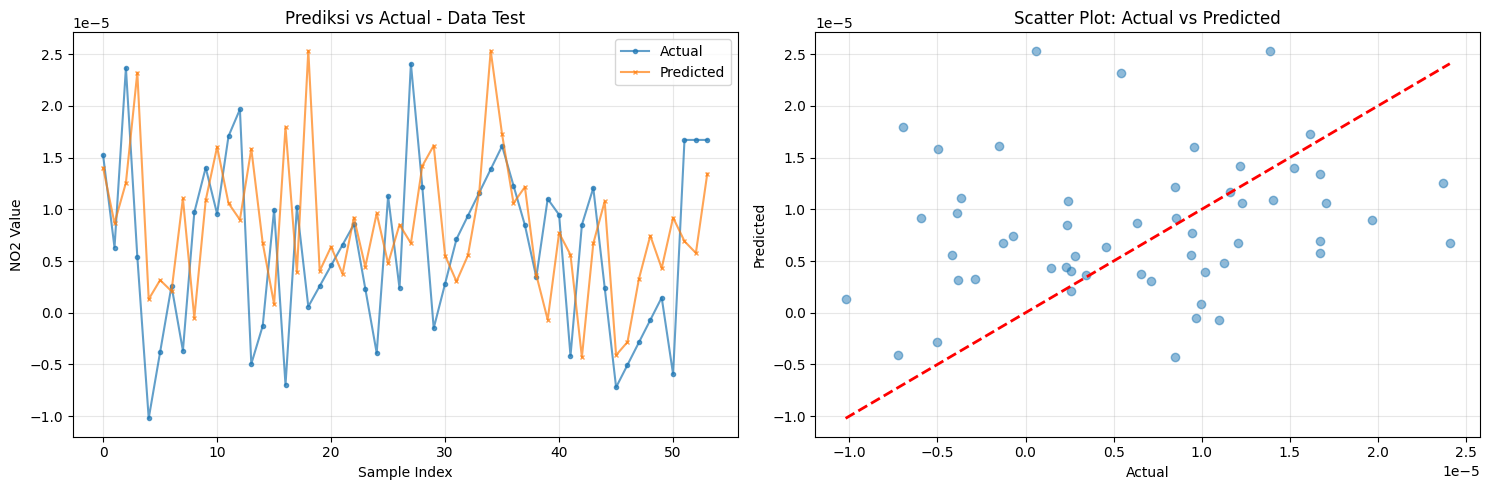

In [ ]:
# Plot prediksi vs actual
plt.figure(figsize=(15, 5))

# Plot 1: Prediksi vs Actual pada data test
plt.subplot(1, 2, 1)
plt.plot(y_test.values, label='Actual', marker='o', markersize=3, alpha=0.7)
plt.plot(y_pred, label='Predicted', marker='x', markersize=3, alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('NO2 Value')
plt.title('Prediksi vs Actual - Data Test')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Scatter plot actual vs predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Scatter Plot: Actual vs Predicted')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

12. Residual Analysis

Ini adalah langkah "post-mortem" 🕵️‍♂️ untuk model Anda. Alih-alih hanya melihat skor akurasi tunggal, Anda sekarang menganalisis **karakter dari kesalahan** yang dibuat model.

**Residual** adalah selisih antara nilai aktual dan nilai prediksi (`Error = Aktual - Prediksi`). Tujuannya adalah untuk memastikan bahwa kesalahan-kesalahan ini **acak (random)** dan tidak memiliki pola. Jika ada pola dalam kesalahan, itu berarti model Anda melewatkan sesuatu yang penting.

---
### 1. Residual Plot (Plot Sisaan)
* **Apa itu?** Ini adalah *scatter plot* dengan nilai **residual (error)** di sumbu Y dan **nilai prediksi** (atau waktu) di sumbu X.
* **Apa yang Diharapkan (Hasil Baik):** Sebuah "awan" titik data yang acak dan tidak berbentuk ☁️, tersebar secara merata di sekitar garis nol.
* **Tanda Bahaya (Hasil Buruk):** Adanya pola.
    * **Bentuk Corong/Terompet:** Kesalahan model menjadi lebih besar untuk prediksi yang lebih besar (*heteroscedasticity*).
    * **Bentuk Kurva (U-shape):** Model Anda secara sistematis gagal menangkap pola non-linear.

### 2. Histogram Distribusi Residual
* **Apa itu?** Menunjukkan seberapa sering model Anda membuat kesalahan besar vs. kecil.
* **Apa yang Diharapkan (Hasil Baik):** Sebuah **kurva lonceng (bell curve) 🔔** yang simetris dan terpusat di angka nol. Ini menunjukkan bahwa sebagian besar kesalahan sangat kecil (mendekati nol), dan kesalahan besar (baik positif maupun negatif) sangat jarang terjadi.
* **Tanda Bahaya (Hasil Buruk):** Plot yang "miring" (skewed) ke satu sisi. Ini berarti model Anda memiliki bias (misalnya, lebih sering sedikit melebih-lebihkan prediksi daripada meremehkannya).

### 3. Q-Q Plot (Cek Normalitas)
* **Apa itu?** Cara teknis untuk membandingkan apakah distribusi error Anda (residual) cocok dengan distribusi normal yang sempurna.
* **Apa yang Diharapkan (Hasil Baik):** Titik-titik data jatuh persis di sepanjang **garis lurus diagonal**.
* **Tanda Bahaya (Hasil Buruk):** Titik-titik data melengkung menjauhi garis lurus, terutama di bagian ujung (ekor). Ini adalah konfirmasi visual bahwa error Anda tidak terdistribusi secara normal.


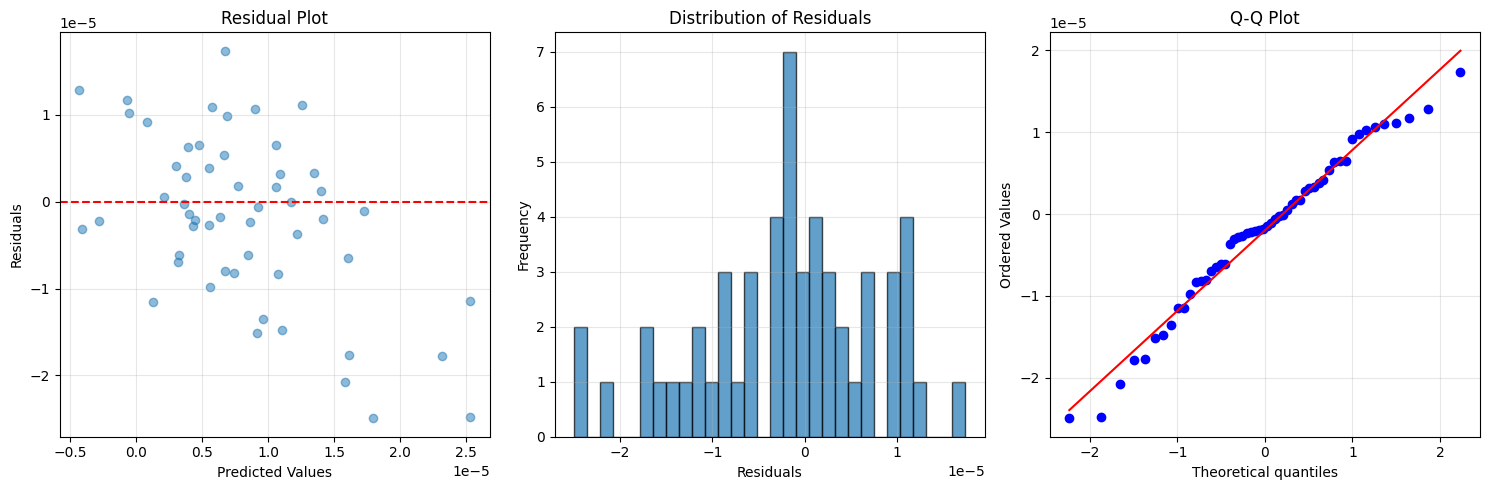

Mean Residual: -0.000002
Std Residual: 0.000010


In [ ]:
# Hitung residual
residuals = y_test.values - y_pred

plt.figure(figsize=(15, 5))

# Plot 1: Residual plot
plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# Plot 2: Histogram residual
plt.subplot(1, 3, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

# Plot 3: Q-Q plot
from scipy import stats
plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.6f}")
print(f"Std Residual: {residuals.std():.6f}")

13. Hyperparameter Tuning - Mencari K Optimal

Ini adalah langkah **optimasi** 🎯. Pilihan `k=3` yang kita gunakan di awal hanyalah tebakan. Sekarang, kita akan mencari nilai `k` terbaik secara sistematis.

## Mengapa Mencari 'k' Optimal?

Nilai `k` sangat memengaruhi perilaku model dan harus diseimbangkan dengan cermat (ini disebut *Bias-Variance Tradeoff*):

* **Jika `k` terlalu kecil (misal, `k=1`):**
    Model menjadi terlalu "sensitif" dan hanya meniru tetangga terdekatnya. Ini akan menghasilkan prediksi yang sangat bergejolak dan **overfitting** (model menghafal data latihan tapi buruk pada data baru). Skor R² di data *training* akan sangat tinggi, tapi di data *testing* akan rendah.

* **Jika `k` terlalu besar (misal, `k=20`):**
    Model menjadi terlalu "sederhana" dan hanya mengambil rata-rata dari banyak tetangga. Ini akan menghasilkan prediksi yang terlalu mulus (rata) dan **underfitting** (model gagal menangkap pola data). Skor R² akan rendah di kedua set data.

## Bagaimana Kita Menemukannya?

Prosesnya adalah "kontes" untuk menemukan nilai `k` yang paling seimbang:

1.  **Iterasi (Looping):** Kita membuat *loop* yang akan mencoba setiap nilai `k`, satu per satu (misal, dari 1, 2, 3, ... hingga 20).
2.  **Latih & Uji Ulang:** Di setiap iterasi, kita melatih model KNN baru dengan nilai `k` tersebut dan menghitung skor R² pada data *training* dan *testing*.
3.  **Bandingkan Hasil:** Kita mengumpulkan semua skor ini ke dalam satu tabel atau plot.

**Plot "Elbow"** adalah cara terbaik untuk melihat hasilnya. Kita mencari "siku"  Elbow:
* Kita ingin `k` yang memberikan **Skor R² Testing tertinggi**.
* Kita juga mencari titik di mana **celah (gap) antara Skor R² Training dan Testing paling kecil**, yang menunjukkan model yang seimbang (tidak *overfitting*).



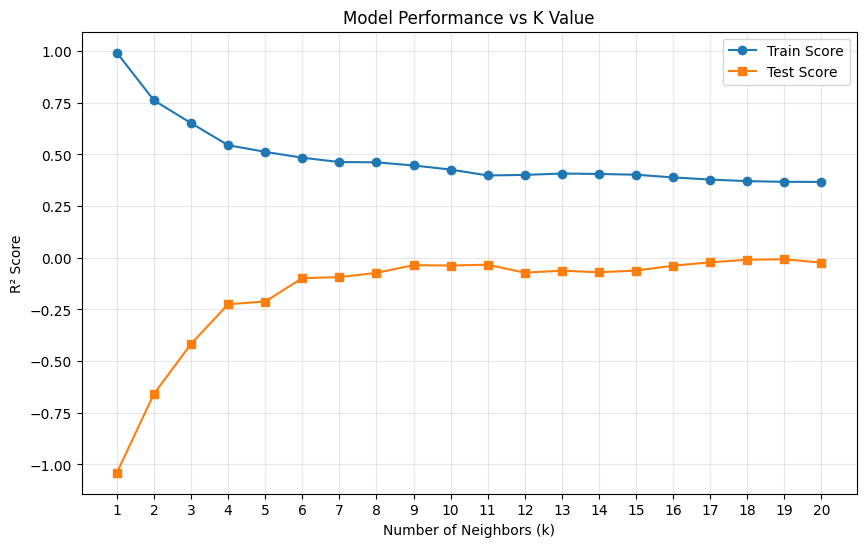


Optimal K: 19
Best Test Score (R²): -0.007469


In [ ]:
# Mencari nilai k optimal
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn_temp = KNeighborsRegressor(n_neighbors=k, weights='uniform')
    knn_temp.fit(X_train_scaled, y_train)

    # Score pada data train
    train_scores.append(knn_temp.score(X_train_scaled, y_train))

    # Score pada data test
    test_scores.append(knn_temp.score(X_test_scaled, y_test))

# Plot hasil
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Train Score', marker='o')
plt.plot(k_range, test_scores, label='Test Score', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R² Score')
plt.title('Model Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

# Cari k optimal
optimal_k = k_range[np.argmax(test_scores)]
print(f"\nOptimal K: {optimal_k}")
print(f"Best Test Score (R²): {max(test_scores):.6f}")

14. Training Model dengan K Optimal

Ini adalah langkah **finalisasi** 🏆. Setelah proses *tuning* (langkah 13) memberi tahu kita nilai `k` mana yang "juara" (misalnya, `k=9`), kita sekarang secara resmi menggunakan nilai tersebut.

Prosesnya adalah:
1.  Kita **membuang** model `k=3` yang lama (yang hanya tebakan awal).
2.  Kita **membuat satu model KNN baru** yang dari awal sudah disetel secara khusus dengan `n_neighbors` = `k` optimal (misalnya, 7).
3.  Kita **melatih ulang (fit)** model baru ini pada data *training*.
4.  Kita **mengevaluasi** performanya pada data *testing*.

Angka evaluasi (R², RMSE, dll.) dari model *optimal* inilah yang menjadi **hasil akhir** dan acuan kita tentang seberapa baik model KNN ini dapat memprediksi data NO2.

In [ ]:
# Pastikan Anda mengimpor fungsi yang diperlukan di awal script Anda
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# --- Asumsi X_train_scaled, y_train, X_test_scaled, y_test, dan optimal_k sudah ada ---

# Training ulang dengan k optimal
knn_optimal = KNeighborsRegressor(n_neighbors=optimal_k, weights='uniform')
knn_optimal.fit(X_train_scaled, y_train)

# Prediksi dengan model optimal
y_pred_optimal = knn_optimal.predict(X_test_scaled)
y_train_pred_optimal = knn_optimal.predict(X_train_scaled)

# Evaluasi model optimal
mse_test_opt = mean_squared_error(y_test, y_pred_optimal)
rmse_test_opt = np.sqrt(mse_test_opt)
mae_test_opt = mean_absolute_error(y_test, y_pred_optimal)
r2_test_opt = r2_score(y_test, y_pred_optimal)
mape_test_opt = mean_absolute_percentage_error(y_test, y_pred_optimal) # <-- MAPE Test

mse_train_opt = mean_squared_error(y_train, y_train_pred_optimal)
rmse_train_opt = np.sqrt(mse_train_opt)
mae_train_opt = mean_absolute_error(y_train, y_train_pred_optimal)
r2_train_opt = r2_score(y_train, y_train_pred_optimal)
mape_train_opt = mean_absolute_percentage_error(y_train, y_train_pred_optimal) # <-- MAPE Train

# --- Output Evaluasi ---
print("="*50)
print(f"MODEL KNN REGRESSION DENGAN K OPTIMAL = {optimal_k}")
print("="*50)
print("\nMetrik pada Data Training:")
print(f"MSE  : {mse_train_opt:.6f}")
print(f"RMSE : {rmse_train_opt:.6f}")
print(f"MAE  : {mae_train_opt:.6f}")
print(f"MAPE : {mape_train_opt:.6f}") # <-- Print MAPE Train
print(f"R²   : {r2_train_opt:.6f}")
print("\nMetrik pada Data Testing:")
print(f"MSE  : {mse_test_opt:.6f}")
print(f"RMSE : {rmse_test_opt:.6f}")
print(f"MAE  : {mae_test_opt:.6f}")
print(f"MAPE : {mape_test_opt:.6f}")  # <-- Print MAPE Test
print(f"R²   : {r2_test_opt:.6f}")
print("="*50)

MODEL KNN REGRESSION DENGAN K OPTIMAL = 19

Metrik pada Data Training:
MSE  : 0.000000
RMSE : 0.000007
MAE  : 0.000005
MAPE : 1.339120
R²   : 0.367563

Metrik pada Data Testing:
MSE  : 0.000000
RMSE : 0.000008
MAE  : 0.000007
MAPE : 1.774862
R²   : -0.007469


15. Perbandingan Model Default vs Optimal

Ini adalah langkah **validasi** ⚖️, di mana kita membuktikan bahwa proses *tuning* (langkah 12) benar-benar ada gunanya.

Kita membandingkan "rapor" (skor R², RMSE, dll.) dari dua model secara berdampingan:

1.  **Model Default (k=5):** Ini adalah model yang kita buat berdasarkan tebakan awal.
2.  **Model Optimal (k=19, misalnya):** Ini adalah model yang kita dapatkan setelah pencarian sistematis untuk nilai `k` terbaik.

**Tujuannya** adalah untuk mengukur seberapa besar peningkatannya. Perbandingan ini secara jelas menunjukkan nilai tambah dari *hyperparameter tuning* dan memberikan keyakinan bahwa model akhir yang kita pilih adalah versi KNN terbaik untuk masalah *time series* NO2 ini.

In [ ]:
# Buat dataframe untuk perbandingan
comparison = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Default (k=5) - Train': [mse_train, rmse_train, mae_train, r2_train],
    'Default (k=5) - Test': [mse_test, rmse_test, mae_test, r2_test],
    f'Optimal (k={optimal_k}) - Train': [mse_train_opt, rmse_train_opt, mae_train_opt, r2_train_opt],
    f'Optimal (k={optimal_k}) - Test': [mse_test_opt, rmse_test_opt, mae_test_opt, r2_test_opt]
})

print("\nPerbandingan Model:")
print(comparison.to_string(index=False))


Perbandingan Model:
Metric  Default (k=5) - Train  Default (k=5) - Test  Optimal (k=19) - Train  Optimal (k=19) - Test
   MSE           2.473610e-11          9.590875e-11            4.491257e-11           6.818068e-11
  RMSE           4.973540e-06          9.793301e-06            6.701684e-06           8.257159e-06
   MAE           3.164348e-06          7.582656e-06            4.615064e-06           6.749415e-06
    R²           6.516781e-01         -4.171911e-01            3.675627e-01          -7.468519e-03


16. Visualisasi Hasil Model Optimal
Visualisasi hasil prediksi model optimal dengan time series plot dan scatter plot untuk mengevaluasi kualitas prediksi secara visual.

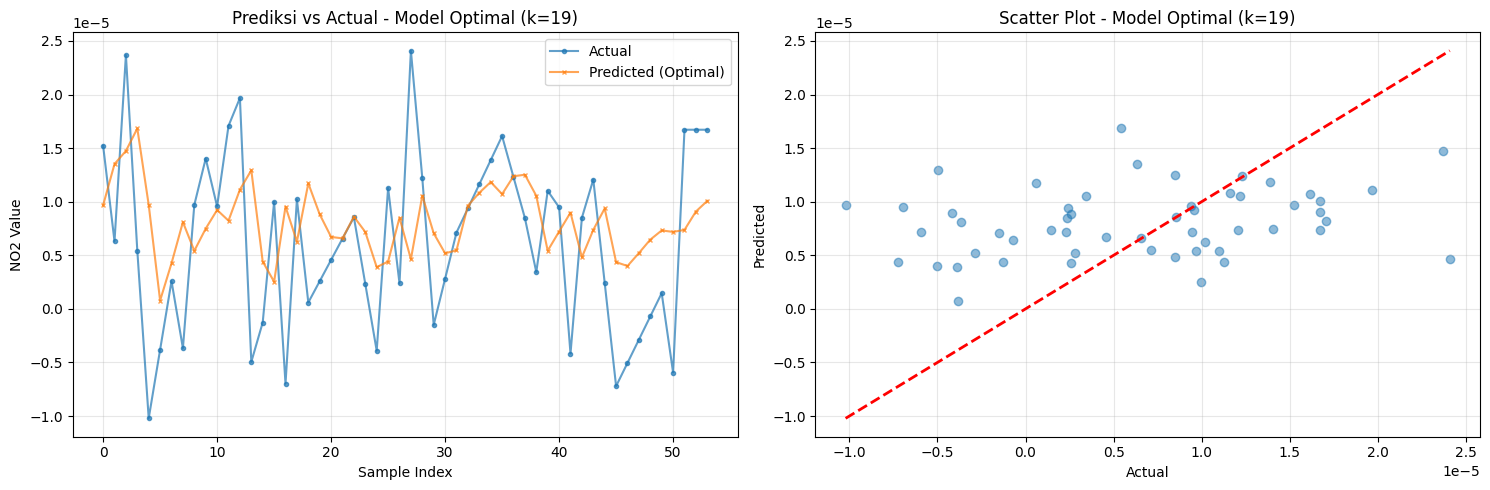

In [ ]:
# Plot hasil prediksi model optimal
plt.figure(figsize=(15, 5))

# Plot 1: Time series comparison
plt.subplot(1, 2, 1)
plt.plot(y_test.values, label='Actual', marker='o', markersize=3, alpha=0.7)
plt.plot(y_pred_optimal, label='Predicted (Optimal)', marker='x', markersize=3, alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('NO2 Value')
plt.title(f'Prediksi vs Actual - Model Optimal (k={optimal_k})')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Scatter plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_optimal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Scatter Plot - Model Optimal (k={optimal_k})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Link dataset

https://drive.google.com/drive/folders/1d4XI0wizxpA28t4YauCrV9Afc885tp19?usp=sharing

In [6]:
# Pastikan Anda menjalankan ini di lingkungan Python 3.9, 3.10, or 3.11
# Anda mungkin perlu menginstal: pip install pycaret[full]

import pandas as pd
from pycaret.time_series import *
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 4.1 PERSIAPAN DATA
# -----------------------------------------------------------------
print("Memulai 4.1 Persiapan Data...")

# Load data Anda
file_path = 'timeseries_NO2_preprocessed.csv'
try:
    df = pd.read_csv(file_path)
    print("Data berhasil di-load.")

    # Tampilkan info dan 5 baris pertama untuk inspeksi
    print("\n--- df.info() ---")
    df.info()
    print("\n--- df.head() ---")
    print(df.head())

    # Asumsi berdasarkan nama file dan snippet:
    # Kolom tanggal adalah 't' dan kolom target adalah 'NO2'

    # 1. Pilih kolom yang relevan
    data_no2 = df[['t', 'NO2']]

    # 2. Konversi 't' ke datetime
    data_no2['t'] = pd.to_datetime(data_no2['t'])

    # 3. Set 't' sebagai index
    data_no2 = data_no2.set_index('t')

    # 4. Pastikan frekuensi harian ('D') dan interpolasi
    # Ini langkah krusial untuk PyCaret
    data_no2 = data_no2.asfreq('D')
    data_no2 = data_no2.interpolate(method='linear')

    print("\nData setelah preprocessing (head):")
    print(data_no2.head())
    print(f"Total data points setelah resampling: {len(data_no2)}")

except FileNotFoundError:
    print(f"Error: File '{file_path}' tidak ditemukan.")
    # Hentikan eksekusi jika file tidak ada
    exit()
except KeyError:
    print("Error: Kolom 't' atau 'NO2' tidak ditemukan. Pastikan nama kolom di file CSV Anda benar.")
    # Hentikan eksekusi jika kolom tidak ada
    exit()
except Exception as e:
    print(f"Terjadi error saat memproses data: {e}")
    exit()

# -----------------------------------------------------------------
# 4.2 SETUP EKSPERIMEN PYCARET
# -----------------------------------------------------------------
print("\nMemulai 4.2 Setup Eksperimen PyCaret...")
# Kita akan meramal 30 hari ke depan
# fold=3 untuk cross-validation, session_id=123 untuk reproduktibilitas
exp = setup(data=data_no2, target='NO2', fh=30, fold=3, session_id=123)
print("Setup PyCaret selesai.")

# -----------------------------------------------------------------
# 4.3 PEMBUATAN DAN PERBANDINGAN MODEL
# -----------------------------------------------------------------
print("\nMemulai 4.3 Perbandingan Model...")
# Bandingkan semua model yang ada di library PyCaret
best_model = compare_models()

print("\nHasil Perbandingan Model (best_model):")
print(best_model)

# -----------------------------------------------------------------
# 4.4 FOKUS PADA EXPONENTIAL SMOOTHING (ETS)
# -----------------------------------------------------------------
print("\nMemulai 4.4 Fokus pada ETS...")
# Buat model 'ets' (Exponential Smoothing) secara spesifik
ets_model = create_model('ets')
print("Detail Model ETS:")
print(ets_model)

# -----------------------------------------------------------------
# 4.5 ANALISIS DAN VISUALISASI HASIL
# -----------------------------------------------------------------
print("\nMemulai 4.5 Analisis Visual...")
# Plot hasil peramalan
# 'save=True' penting agar gambar disimpan
plot_model(ets_model, plot='forecast', save=True, file_name='ets_forecast_plot.png')
print("Plot peramalan disimpan sebagai 'ets_forecast_plot.png'")

# Plot dekomposisi data (Trend, Seasonality, Residual)
plot_model(ets_model, plot='decomp', save=True, file_name='ets_decomp_plot.png')
print("Plot dekomposisi disimpan sebagai 'ets_decomp_plot.png'")

# -----------------------------------------------------------------
# 4.6 FINALISASI DAN PREDIKSI AKHIR
# -----------------------------------------------------------------
print("\nMemulai 4.6 Finalisasi Model dan Prediksi...")
# Finalisasi model (melatih ulang dengan semua data)
final_ets = finalize_model(ets_model)

# Lakukan peramalan 30 hari ke depan
predictions = predict_model(final_ets)

print("\nHasil Peramalan 30 Hari ke Depan (predictions):")
print(predictions.tail(30)) # Tampilkan 30 baris peramalan

print("\n--- EKSEKUSI SELESAI ---")

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')